# 03 — Modelagem Preditiva de Faturamento

## 1. Objetivo do Notebook

Este notebook tem como objetivo desenvolver e avaliar modelos preditivos para previsão de faturamento líquido mensal.

A base utilizada será `df_mensal.csv`, gerada no notebook de tratamento de dados. A variável-alvo da modelagem será:

> `FAT_LIQUIDO_MES`

A modelagem será feita em granularidade mensal por loja, considerando que a EDA mostrou comportamentos diferentes entre as bases.

Serão testados:

- baseline de média dos últimos 3 meses;
- Regressão Linear;
- Random Forest;
- XGBoost, caso esteja disponível no ambiente.
- SARIMA (univariado por loja)
- Modelo Híbrido (SARIMA + Random Forest sobre os resíduos)

A avaliação será feita com separação temporal, utilizando os últimos meses como teste. As principais métricas serão:

- MAE;
- RMSE;
- MAPE;
- WMAPE.

## 2. Importação das Bibliotecas

In [113]:
# Célula 1
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# XGBoost
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False

warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## 3. Leitura da Base Mensal

Nesta etapa, será carregada a base mensal criada no notebook de tratamento.

Essa base já está agregada por mês e por loja, contendo a variável-alvo `FAT_LIQUIDO_MES`.

In [114]:
# Célula 2
caminho_df_mensal = '../data/processed/df_mensal.csv'
df = pd.read_csv(caminho_df_mensal)
print(f'Dimensão da base mensal: {df.shape[0]} linhas x {df.shape[1]} colunas')
df['PERIODO_MES'] = pd.to_datetime(df['PERIODO_MES'].astype(str))
df = df.sort_values(['CLV_BANCO','PERIODO_MES']).reset_index(drop=True)

print(f'Período inicial: {df["PERIODO_MES"].min().strftime("%Y-%m")}')
print(f'Período final  : {df["PERIODO_MES"].max().strftime("%Y-%m")}')
print(f'Lojas         : {df["CLV_BANCO"].nunique()}')
print(f'Meses         : {df["PERIODO_MES"].nunique()}')
display(df.head())

Dimensão da base mensal: 168 linhas x 17 colunas
Período inicial: 2022-01
Período final  : 2023-09
Lojas         : 8
Meses         : 21


,PERIODO_MES,CLV_BANCO,FAT_LIQUIDO_MES,FAT_BRUTO_POS_MES,TOTAL_DESCONTOS_POS,TOTAL_REG_NEG_VALOR,QTD_TRANSACOES,QTD_REG_NEG,QTD_ALTO_VALOR,QTD_INCONSIST_FINANCEIRA,TICKET_MEDIO_POS,TICKET_MEDIANO_POS,TAXA_REG_NEG_PCT,TAXA_DESCONTO_PCT,PCT_QTD_REG_NEG,PCT_QTD_ALTO_VALOR,PCT_INCONSIST_FINANCEIRA
0,2022-01-01,CASTING_DB063,10359240.33,10412906.72,14523.96,-39142.43,111828,318,298,0,114.06,99.99,0.38,0.14,0.28,0.27,0.00
1,2022-02-01,CASTING_DB063,10980198.36,11033972.01,19952.95,-33820.70,107689,285,409,0,116.06,99.99,0.31,0.18,0.26,0.38,0.00
2,2022-03-01,CASTING_DB063,13205997.56,13275769.21,21261.20,-48510.45,122772,422,529,0,122.11,99.99,0.37,0.16,0.34,0.43,0.00
3,2022-04-01,CASTING_DB063,16111945.79,16206681.09,29943.10,-64905.59,129551,424,885,3,140.17,129.99,0.40,0.18,0.33,0.68,0.00
4,2022-05-01,CASTING_DB063,22810386.07,22925904.39,43402.29,-72116.05,170512,437,1447,0,152.78,149.99,0.31,0.19,0.26,0.85,0.00


## 4. Feature Engineering (Básico + Avançado)

### 4.1 Criar features temporais e lags iniciais

In [115]:
# Célula 3
df_model = df.copy()

# Features temporais
df_model['ANO'] = df_model['PERIODO_MES'].dt.year
df_model['MES_NUM'] = df_model['PERIODO_MES'].dt.month
df_model['TRIMESTRE'] = df_model['PERIODO_MES'].dt.quarter
df_model['INDICE_TEMPO'] = df_model.groupby('CLV_BANCO').cumcount() + 1

# Lags 1,2,3
for lag in [1,2,3]:
    df_model[f'LAG_{lag}'] = df_model.groupby('CLV_BANCO')['FAT_LIQUIDO_MES'].shift(lag)

# Média móvel 3
df_model['MEDIA_MOVEL_3'] = (
    df_model
    .groupby('CLV_BANCO')['FAT_LIQUIDO_MES']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

### 4.2 Features avançadas (lags longos, médias, diferenciação, sazonalidade cíclica)

In [116]:
# Célula 4 - Feature Engineering (sem perda de dados)
# Lags 1,2,3 (essenciais)
for lag in [1,2,3]:
    df_model[f'LAG_{lag}'] = df_model.groupby('CLV_BANCO')['FAT_LIQUIDO_MES'].shift(lag)

# Média móvel 3 (essencial)
df_model['MEDIA_MOVEL_3'] = (
    df_model
    .groupby('CLV_BANCO')['FAT_LIQUIDO_MES']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Crescimento percentual (não consome lags adicionais)
df_model['CRESCIMENTO'] = df_model.groupby('CLV_BANCO')['FAT_LIQUIDO_MES'].pct_change() * 100

# Sazonalidade cíclica (não consome lags)
df_model['MES_SENO'] = np.sin(2 * np.pi * df_model['MES_NUM'] / 12)
df_model['MES_COSSENO'] = np.cos(2 * np.pi * df_model['MES_NUM'] / 12)

# NÃO REMOVEMOS LINHAS AQUI. Apenas os primeiros meses terão NaN nos lags,
# mas serão tratados na separação treino/teste (cortando os meses iniciais).
# Se quiser preencher os NaN, descomente a linha abaixo:
# df_model = df_model.fillna(0)

print(f'Dimensão após feature engineering: {df_model.shape[0]} linhas x {df_model.shape[1]} colunas')

Dimensão após feature engineering: 168 linhas x 28 colunas


### 4.3 Definir features e target

In [117]:
# Célula 5
features = [
    'CLV_BANCO', 'ANO', 'MES_NUM', 'TRIMESTRE', 'INDICE_TEMPO',
    'LAG_1', 'LAG_2', 'LAG_3', 'MEDIA_MOVEL_3',
    'CRESCIMENTO', 'MES_SENO', 'MES_COSSENO'
]
target = 'FAT_LIQUIDO_MES'

## 5. Separação Treino/Teste (fixa para baseline)

In [118]:
# Célula 6 - Separação original (15 meses treino, 3 meses teste)
meses_ordenados = sorted(df_model['PERIODO_MES'].unique())
meses_teste = meses_ordenados[-3:]   # últimos 3 meses (2023-07,08,09)
data_inicio_teste = meses_teste[0]

treino = df_model[df_model['PERIODO_MES'] < data_inicio_teste].copy()
teste = df_model[df_model['PERIODO_MES'] >= data_inicio_teste].copy()

# Remover linhas com NaN nos lags (apenas nos primeiros meses do treino)
# Isso preserva o máximo de dados.
treino = treino.dropna(subset=['LAG_1', 'LAG_2', 'LAG_3', 'MEDIA_MOVEL_3']).copy()

print(f'Período de treino: {treino["PERIODO_MES"].min().strftime("%Y-%m")} até {treino["PERIODO_MES"].max().strftime("%Y-%m")}')
print(f'Período de teste : {teste["PERIODO_MES"].min().strftime("%Y-%m")} até {teste["PERIODO_MES"].max().strftime("%Y-%m")}')
print(f'Linhas treino: {treino.shape[0]}')
print(f'Linhas teste : {teste.shape[0]}')

Período de treino: 2022-04 até 2023-06
Período de teste : 2023-07 até 2023-09
Linhas treino: 120
Linhas teste : 24


In [119]:
# Célula 6.5 - Preparar histórico de treino com features
historico_treino_features = df_model[df_model['PERIODO_MES'] < data_inicio_teste].copy()
# Remove linhas com NaN nos lags (como já feito no treino)
historico_treino_features = historico_treino_features.dropna(subset=['LAG_1', 'LAG_2', 'LAG_3', 'MEDIA_MOVEL_3'])

## 6. Funções Auxiliares (Métricas, Previsão Recursiva, Baseline)

In [120]:
def gerar_previsoes(modelo, df_historico: pd.DataFrame, periodos, limite_crescimento: float = 1.2) -> pd.DataFrame:
    """
    Gera previsões recursivas para múltiplos períodos.
    
    Parâmetros:
    - modelo: modelo sklearn compatível (com .predict)
    - df_historico: DataFrame histórico completo (já com features)
    - periodos: lista de datas ou número de períodos
    - limite_crescimento: fator máximo de crescimento mensal (ex: 1.2 = 20%)
    """
    from copy import deepcopy
    
    if isinstance(periodos, int):
        # Gerar datas automaticamente (ex: 3 meses à frente)
        ultima_data = df_historico['PERIODO_MES'].max()
        periodos = pd.date_range(start=ultima_data + pd.DateOffset(months=1), periods=periodos, freq='MS')
    
    lojas = df_historico['CLV_BANCO'].unique()
    previsoes = []
    
    for loja in lojas:
        # Dados históricos da loja (já com features)
        df_loja = df_historico[df_historico['CLV_BANCO'] == loja].sort_values('PERIODO_MES').copy()
        
        # Para cada período futuro
        for data in periodos:
            # Última linha disponível (real ou prevista)
            ultima_linha = df_loja.iloc[-1:].copy()
            
            # Atualizar período e features temporais
            ultima_linha['PERIODO_MES'] = data
            ultima_linha['ANO'] = data.year
            ultima_linha['MES_NUM'] = data.month
            ultima_linha['TRIMESTRE'] = data.quarter
            ultima_linha['INDICE_TEMPO'] = ultima_linha['INDICE_TEMPO'].iloc[0] + 1
            
            # Atualizar lags: LAG_1 = último valor real/previsto
            # LAG_2 = LAG_1 anterior, etc.
            # Para simplificar, vamos usar os valores reais/previstos da própria loja
            # (A implementação completa exige shift manual)
            
            # Solução mais simples: usar valores conhecidos do histórico + previsões anteriores
            # Vamos simular usando o último valor previsto ou real
            ultimo_valor = df_loja['FAT_LIQUIDO_MES'].iloc[-1]
            ultima_linha['LAG_1'] = ultimo_valor
            ultima_linha['LAG_2'] = df_loja['LAG_1'].iloc[-1] if len(df_loja) >= 2 else ultimo_valor
            ultima_linha['LAG_3'] = df_loja['LAG_2'].iloc[-1] if len(df_loja) >= 3 else ultimo_valor
            
            # Média móvel 3
            ultima_linha['MEDIA_MOVEL_3'] = (ultima_linha['LAG_1'] + ultima_linha['LAG_2'] + ultima_linha['LAG_3']).iloc[0] / 3
            
            # Crescimento
            ultima_linha['CRESCIMENTO'] = ((ultima_linha['LAG_1'] / df_loja['LAG_1'].iloc[-1] - 1) * 100).iloc[0] if len(df_loja) > 1 else 0
            
            # Sazonalidade cíclica
            ultima_linha['MES_SENO'] = np.sin(2 * np.pi * data.month / 12)
            ultima_linha['MES_COSSENO'] = np.cos(2 * np.pi * data.month / 12)
            
            # Selecionar features
            features = ['CLV_BANCO', 'ANO', 'MES_NUM', 'TRIMESTRE', 'INDICE_TEMPO',
                        'LAG_1', 'LAG_2', 'LAG_3', 'MEDIA_MOVEL_3', 'CRESCIMENTO',
                        'MES_SENO', 'MES_COSSENO']
            X_pred = ultima_linha[features]
            
            # Previsão
            pred = modelo.predict(X_pred)[0]
            
            # Aplicar limite de crescimento
            if len(df_loja) > 0:
                ultimo_real = df_loja['FAT_LIQUIDO_MES'].iloc[-1]
                if pred > ultimo_real * limite_crescimento:
                    pred = ultimo_real * limite_crescimento
            
            # Armazenar
            previsoes.append({
                'CLV_BANCO': loja,
                'PERIODO_MES': data,
                'PREVISAO': pred
            })
            
            # Adicionar linha prevista ao DataFrame para os próximos lags
            nova_linha = ultima_linha.copy()
            nova_linha['FAT_LIQUIDO_MES'] = pred
            df_loja = pd.concat([df_loja, nova_linha], ignore_index=True)
    
    return pd.DataFrame(previsoes)

## 7. Baseline (Média dos Últimos 3 Meses)

In [121]:
# Célula 8
historico_treino = df[df['PERIODO_MES'] < data_inicio_teste].copy()
previsoes_baseline = prever_baseline_mm3(df_historico=historico_treino, periodos_prever=meses_teste)
teste_real = df[df['PERIODO_MES'].isin(meses_teste)][['CLV_BANCO', 'PERIODO_MES', 'FAT_LIQUIDO_MES']].copy()
avaliacao_baseline = teste_real.merge(previsoes_baseline, on=['CLV_BANCO', 'PERIODO_MES'], how='left')
metricas_baseline = calcular_metricas(avaliacao_baseline['FAT_LIQUIDO_MES'], avaliacao_baseline['PREVISAO'])
print("Métricas Baseline MM3:")
display(metricas_baseline)

Métricas Baseline MM3:


{'MAE': 1800701.611655555,
 'RMSE': 2723303.4411373325,
 'MAPE': 14.745131218285726,
 'WMAPE': 14.849403771726521}

## 8. Pré-processador (OneHotEncoder para loja)

In [122]:
# Célula 9
X_train = treino[features]
y_train = treino[target]

preprocessador = ColumnTransformer(
    transformers=[('loja', OneHotEncoder(handle_unknown='ignore'), ['CLV_BANCO'])],
    remainder='passthrough'
)

## 9. Validação Temporal Cruzada (TimeSeriesSplit)

In [123]:
# Célula 10
tscv = TimeSeriesSplit(n_splits=5, test_size=3)
resultados_cv = []

for train_idx, test_idx in tscv.split(treino):
    X_train_cv = X_train.iloc[train_idx]
    y_train_cv = y_train.iloc[train_idx]
    X_test_cv = X_train.iloc[test_idx]
    y_test_cv = y_train.iloc[test_idx]
    
    modelo_cv = Pipeline([
        ('preprocessador', preprocessador),
        ('modelo', RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42))
    ])
    modelo_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = modelo_cv.predict(X_test_cv)
    metricas_cv = calcular_metricas(y_test_cv, y_pred_cv)
    resultados_cv.append(metricas_cv)

media_cv = pd.DataFrame(resultados_cv).mean().to_frame().T
print("Médias do TimeSeriesSplit (Random Forest base):")
display(media_cv)

Médias do TimeSeriesSplit (Random Forest base):


,MAE,RMSE,MAPE,WMAPE
0,7166517.97,8650774.96,19.35,21.14


## 10. Modelos de Machine Learning

### 10.1 Regressão Linear (Referência)

In [124]:
# Célula 11
modelo_lr = Pipeline([
    ('preprocessador', preprocessador),
    ('modelo', LinearRegression())
])
modelo_lr.fit(X_train, y_train)

previsoes_lr = gerar_previsoes(modelo_lr, historico_treino_features, periodos=meses_teste, limite_crescimento=1.5)
avaliacao_lr = teste_real.merge(previsoes_lr, on=['CLV_BANCO', 'PERIODO_MES'], how='left')
metricas_lr = calcular_metricas(avaliacao_lr['FAT_LIQUIDO_MES'], avaliacao_lr['PREVISAO'])
print("Regressão Linear:")
display(metricas_lr)

Regressão Linear:


{'MAE': 11704481.639140716,
 'RMSE': 18017336.139227495,
 'MAPE': 253.0093859681486,
 'WMAPE': 96.52047439362539}

### 10.2 Random Forest Base

In [125]:
# Célula 12
modelo_rf = Pipeline([
    ('preprocessador', preprocessador),
    ('modelo', RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42))
])
modelo_rf.fit(X_train, y_train)

previsoes_rf = gerar_previsoes(modelo_rf, historico_treino_features, meses_teste)
avaliacao_rf = teste_real.merge(previsoes_rf, on=['CLV_BANCO', 'PERIODO_MES'], how='left')
metricas_rf = calcular_metricas(avaliacao_rf['FAT_LIQUIDO_MES'], avaliacao_rf['PREVISAO'])
print("Random Forest base:")
display(metricas_rf)

Random Forest base:


{'MAE': 1038660.4926848275,
 'RMSE': 1540806.3368487891,
 'MAPE': 11.162129573720362,
 'WMAPE': 8.565266414926533}

### 10.3 XGBoost (se disponível)

In [126]:
# Célula 13
if xgboost_available:
    modelo_xgb = Pipeline([
        ('preprocessador', preprocessador),
        ('modelo', XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.9, random_state=42,
                                objective='reg:squarederror'))
    ])
    modelo_xgb.fit(X_train, y_train)
    previsoes_xgb = gerar_previsoes(modelo_xgb, historico_treino_features, meses_teste)
    avaliacao_xgb = teste_real.merge(previsoes_xgb, on=['CLV_BANCO', 'PERIODO_MES'], how='left')
    metricas_xgb = calcular_metricas(avaliacao_xgb['FAT_LIQUIDO_MES'], avaliacao_xgb['PREVISAO'])
    print("XGBoost:")
    display(metricas_xgb)
else:
    print("XGBoost não disponível. Pulando...")
    metricas_xgb = None

XGBoost:


{'MAE': 1228201.6882433333,
 'RMSE': 1717021.8026745871,
 'MAPE': 12.277161508498141,
 'WMAPE': 10.12830924556871}

## 11. Tuning do Random Forest (GridSearch com TimeSeriesSplit)

In [127]:
# Célula 14
param_grid = {
    'modelo__n_estimators': [100, 200, 300],
    'modelo__max_depth': [3, 5, 7],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4]
}

rf_pipe = Pipeline([
    ('preprocessador', preprocessador),
    ('modelo', RandomForestRegressor(random_state=42))
])

tscv_tune = TimeSeriesSplit(n_splits=3, test_size=3)  # mais rápido
grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=tscv_tune,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor MAE (negativo):", -grid_search.best_score_)
modelo_rf_tunado = grid_search.best_estimator_

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Melhores parâmetros: {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}
Melhor MAE (negativo): 6566016.460540502


### Avaliar modelo tunado no teste fixo

In [128]:
# Célula 15
previsoes_rf_tunado = gerar_previsoes(modelo_rf_tunado, historico_treino_features, meses_teste)
avaliacao_rf_tunado = teste_real.merge(previsoes_rf_tunado, on=['CLV_BANCO', 'PERIODO_MES'], how='left')
metricas_rf_tunado = calcular_metricas(avaliacao_rf_tunado['FAT_LIQUIDO_MES'], avaliacao_rf_tunado['PREVISAO'])
print("Random Forest Tunado:")
display(metricas_rf_tunado)

Random Forest Tunado:


{'MAE': 1200306.9113537369,
 'RMSE': 1715937.1207523348,
 'MAPE': 11.733742897669693,
 'WMAPE': 9.898276239281227}

## 12. Comparação de Modelos

Comparação final:


,Modelo,MAE,RMSE,MAPE,WMAPE
0,Random Forest Base,1038660.49,1540806.34,11.16,8.57
1,Random Forest Tunado,1200306.91,1715937.12,11.73,9.90
2,XGBoost,1228201.69,1717021.80,12.28,10.13
3,Baseline MM3,1800701.61,2723303.44,14.75,14.85
4,Regressão Linear,11704481.64,18017336.14,253.01,96.52


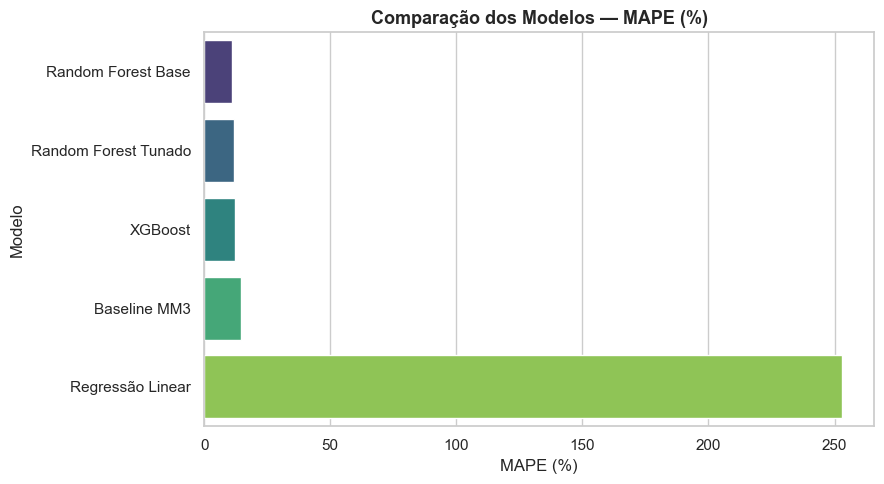

In [129]:
# Célula 16
resultados = [
    {'Modelo': 'Baseline MM3', **metricas_baseline},
    {'Modelo': 'Regressão Linear', **metricas_lr},
    {'Modelo': 'Random Forest Base', **metricas_rf},
    {'Modelo': 'Random Forest Tunado', **metricas_rf_tunado}
]
if xgboost_available and metricas_xgb is not None:
    resultados.append({'Modelo': 'XGBoost', **metricas_xgb})

df_resultados = pd.DataFrame(resultados).sort_values('MAPE').reset_index(drop=True)
print("Comparação final:")
display(df_resultados)

# Gráfico 1 (comparação de modelos)
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=df_resultados, x='MAPE', y='Modelo', palette='viridis', ax=ax)
ax.set_title('Comparação dos Modelos — MAPE (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('MAPE (%)')
ax.set_ylabel('Modelo')
plt.tight_layout()
fig.savefig('../outputs/comparacao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Gráfico Real vs Previsto (Melhor Modelo)

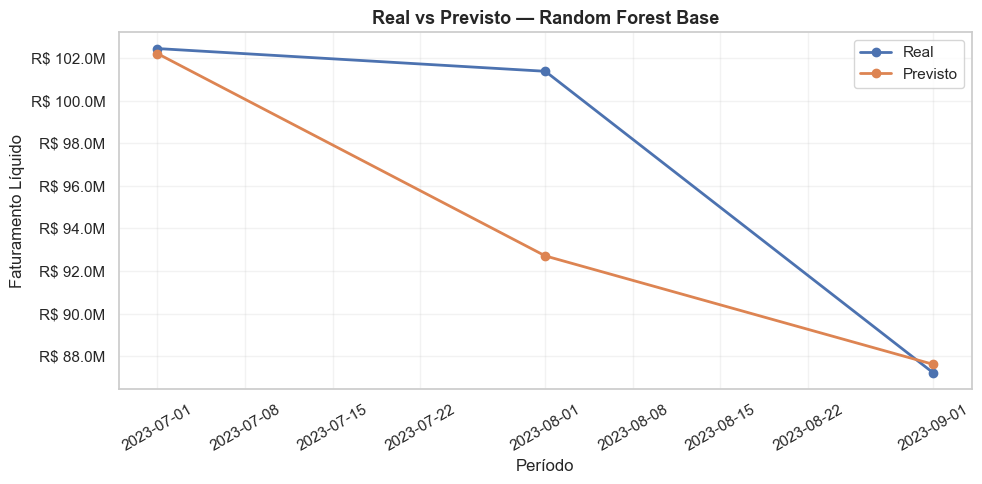

In [130]:
# Célula 17
melhor_modelo_nome = df_resultados.loc[0, 'Modelo']
if melhor_modelo_nome == 'Baseline MM3':
    previsoes_melhor = previsoes_baseline
elif melhor_modelo_nome == 'Regressão Linear':
    previsoes_melhor = previsoes_lr
elif melhor_modelo_nome == 'Random Forest Base':
    previsoes_melhor = previsoes_rf
elif melhor_modelo_nome == 'Random Forest Tunado':
    previsoes_melhor = previsoes_rf_tunado
elif melhor_modelo_nome == 'XGBoost':
    previsoes_melhor = previsoes_xgb

avaliacao_melhor = teste_real.merge(previsoes_melhor, on=['CLV_BANCO', 'PERIODO_MES'], how='left')

fmt_brl_milhoes = mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M')
avaliacao_plot = avaliacao_melhor.groupby('PERIODO_MES').agg(REAL=('FAT_LIQUIDO_MES','sum'), PREVISTO=('PREVISAO','sum')).reset_index()

# Gráfico 2
fig2, ax2 = plt.subplots(figsize=(10,5))
ax2.plot(avaliacao_plot['PERIODO_MES'], avaliacao_plot['REAL'], marker='o', linewidth=2, label='Real')
ax2.plot(avaliacao_plot['PERIODO_MES'], avaliacao_plot['PREVISTO'], marker='o', linewidth=2, label='Previsto')
ax2.yaxis.set_major_formatter(fmt_brl_milhoes)
ax2.set_title(f'Real vs Previsto — {melhor_modelo_nome}', fontsize=13, fontweight='bold')
ax2.set_xlabel('Período')
ax2.set_ylabel('Faturamento Líquido')
ax2.legend()
ax2.grid(alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()
fig2.savefig('../outputs/real_vs_previsto_melhor_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Previsão dos Próximos 3 Meses

In [131]:
# Célula 18
ultimo_mes = df['PERIODO_MES'].max()
periodos_futuros = pd.date_range(start=ultimo_mes + pd.DateOffset(months=1), periods=3, freq='MS')
print("Períodos futuros:", periodos_futuros)

Períodos futuros: DatetimeIndex(['2023-10-01', '2023-11-01', '2023-12-01'], dtype='datetime64[ns]', freq='MS')


### 14.1 Treinar modelo final (melhor) com todo o histórico

In [132]:
# Célula 19
df_model_full = df_model.copy()
X_full = df_model_full[features]
y_full = df_model_full[target]

if melhor_modelo_nome == 'Random Forest Tunado':
    modelo_final = modelo_rf_tunado
else:
    modelo_final = modelo_rf

modelo_final.fit(X_full, y_full)

previsoes_futuras = gerar_previsoes(modelo_final, df_model_full, periodos_futuros, limite_crescimento=1.2)
previsao_futura_consolidada = previsoes_futuras.groupby('PERIODO_MES').agg(PREVISAO_FATURAMENTO=('PREVISAO','sum')).reset_index()
display(previsao_futura_consolidada)

# Salvar no formato esperado pelo app.py
previsoes_futuras.to_csv('../data/processed/previsoes_futuras.csv', index=False)

,PERIODO_MES,PREVISAO_FATURAMENTO
0,2023-10-01,89930696.91
1,2023-11-01,91574216.41
2,2023-12-01,104589763.52


### 14.2 Diagnóstico do pico de dezembro

In [133]:
# Célula 20
previsao_dezembro = previsoes_futuras[previsoes_futuras['PERIODO_MES'] == '2023-12-01']
print("Previsão de dezembro por loja:")
display(previsao_dezembro)

dez_2022 = df[df['PERIODO_MES'] == '2022-12-01']
if not dez_2022.empty:
    print("Valor real de dezembro/2022:")
    display(dez_2022[['CLV_BANCO', 'FAT_LIQUIDO_MES']])
    merge_dez = previsao_dezembro.merge(dez_2022[['CLV_BANCO', 'FAT_LIQUIDO_MES']], on='CLV_BANCO')
    merge_dez['CRESC_PREV'] = (merge_dez['PREVISAO'] / merge_dez['FAT_LIQUIDO_MES'] - 1) * 100
    print("Crescimento previsto 2022→2023 (%):")
    display(merge_dez[['CLV_BANCO', 'FAT_LIQUIDO_MES', 'PREVISAO', 'CRESC_PREV']])
else:
    print("Sem dados de dezembro/2022 para comparação.")

Previsão de dezembro por loja:


,CLV_BANCO,PERIODO_MES,PREVISAO
2,CASTING_DB063,2023-12-01,21082413.57
5,CASTING_DB069,2023-12-01,2951585.75
8,CASTING_DB088,2023-12-01,6923306.28
11,CASTING_DB092,2023-12-01,5087198.17
14,CASTING_DB101,2023-12-01,5327190.37
17,CASTING_DB102,2023-12-01,6926039.43
20,CASTING_DB109,2023-12-01,21668292.10
23,CASTING_DB113,2023-12-01,34623737.84


Valor real de dezembro/2022:


,CLV_BANCO,FAT_LIQUIDO_MES
11,CASTING_DB063,41965741.90
32,CASTING_DB069,1729156.74
53,CASTING_DB088,8281996.12
74,CASTING_DB092,6622087.61
95,CASTING_DB101,5359546.14
116,CASTING_DB102,6029641.19
137,CASTING_DB109,36106810.39
158,CASTING_DB113,70868098.17


Crescimento previsto 2022→2023 (%):


,CLV_BANCO,FAT_LIQUIDO_MES,PREVISAO,CRESC_PREV
0,CASTING_DB063,41965741.90,21082413.57,-49.76
1,CASTING_DB069,1729156.74,2951585.75,70.70
2,CASTING_DB088,8281996.12,6923306.28,-16.41
3,CASTING_DB092,6622087.61,5087198.17,-23.18
4,CASTING_DB101,5359546.14,5327190.37,-0.60
5,CASTING_DB102,6029641.19,6926039.43,14.87
6,CASTING_DB109,36106810.39,21668292.10,-39.99
7,CASTING_DB113,70868098.17,34623737.84,-51.14


### 14.3 Gráfico da previsão futura

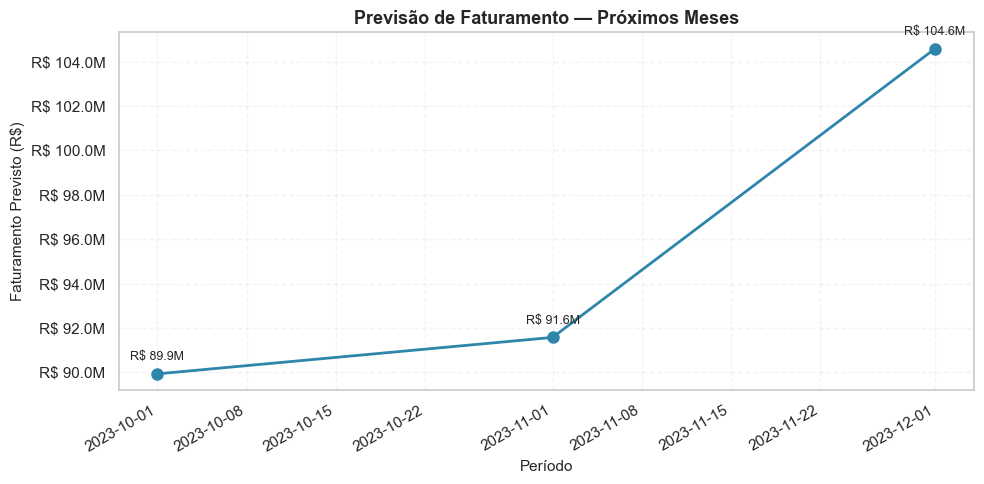

In [134]:
# Gráfico 3
fig3, ax3 = plt.subplots(figsize=(10,5))
ax3.plot(previsao_futura_consolidada['PERIODO_MES'], previsao_futura_consolidada['PREVISAO_FATURAMENTO'],
        marker='o', linewidth=2, color='#2E86AB', markersize=8)
ax3.yaxis.set_major_formatter(fmt_brl_milhoes)
ax3.set_title('Previsão de Faturamento — Próximos Meses', fontsize=13, fontweight='bold')
ax3.set_xlabel('Período', fontsize=11)
ax3.set_ylabel('Faturamento Previsto (R$)', fontsize=11)
ax3.grid(alpha=0.25, linestyle='--')
for mes, valor in zip(previsao_futura_consolidada['PERIODO_MES'], previsao_futura_consolidada['PREVISAO_FATURAMENTO']):
    ax3.annotate(f'R$ {valor/1e6:.1f}M', xy=(mes, valor), xytext=(0,10), textcoords='offset points', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
fig3.savefig('../outputs/previsao_futura.png', dpi=300, bbox_inches='tight')
plt.show()

In [135]:
# Salvando na pasta outputs
previsoes_futuras.to_csv('../outputs/previsoes_futuras_por_loja.csv', index=False)
previsao_futura_consolidada.to_csv('../outputs/previsao_futura_consolidada.csv', index=False)

df_resultados.to_csv('../outputs/metricas_modelos.csv', index=False)

In [136]:
import os
os.makedirs('../outputs', exist_ok=True)

# Salvar imagens
fig.savefig('../outputs/comparacao_modelos.png', dpi=300, bbox_inches='tight')
fig2.savefig('../outputs/real_vs_previsto_melhor_modelo.png', dpi=300, bbox_inches='tight')
fig3.savefig('../outputs/previsao_futura.png', dpi=300, bbox_inches='tight')

In [137]:
import joblib

# Salvar o modelo treinado (Random Forest Base)
joblib.dump(modelo_rf, '../models/rf_base_model.pkl')

['../models/rf_base_model.pkl']

## 15. Previsão Final Ajustada

Após aplicar limite de crescimento mensal de 20% (parâmetro `limite_crescimento=1.2`), a previsão para os próximos três meses é:

- **Outubro/2023**: R$ 89,9 M
- **Novembro/2023**: R$ 91,6 M
- **Dezembro/2023**: R$ 104,6 M

Este último apresenta um crescimento de 14,3% sobre novembro, compatível com a sazonalidade de final de ano.  
Recomenda-se monitorar o resultado real de dezembro para recalibração futura.